<a href="https://colab.research.google.com/github/Deepu9981/FitPulse-Health-Anomaly-Detection-from-Fitness-Devices/blob/main/preprocess_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np

In [52]:
data=pd.read_csv('/content/drive/MyDrive/dataset fitpulse.csv')

In [8]:
def load_data(file_path):
    """
    Load CSV or JSON file into a Pandas DataFrame
    """
    if file_path.endswith(".csv"):
        return pd.read_csv(file_path)
    elif file_path.endswith(".json"):
        return pd.read_json(file_path)
    else:
        raise ValueError("Unsupported file format")


In [9]:
def validate_schema(df, required_columns, dataset_name):
    """
    Ensure required columns exist
    """
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"{dataset_name} missing columns: {missing_cols}")
    print(f"{dataset_name} schema validated ✔")


In [10]:
def normalize_timestamp(df, time_col):
    """
    Convert timestamp column to UTC datetime
    """
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df = df.dropna(subset=[time_col])
    df = df.set_index(time_col)
    return df


In [11]:
def preprocess_heart_rate(hr_df):
    validate_schema(hr_df, ["Time", "Value"], "Heart Rate")

    hr_df = normalize_timestamp(hr_df, "Time")
    hr_df = hr_df.rename(columns={"Value": "HeartRate"})

    # Resample to 1-minute intervals (updated from 'T' to 'min')
    hr_df = hr_df.resample("1min").mean()

    # Handle missing values
    hr_df["HeartRate"] = hr_df["HeartRate"].interpolate()

    return hr_df

In [12]:
def preprocess_steps(steps_df):
    validate_schema(steps_df, ["ActivityDate", "TotalSteps"], "Steps")

    steps_df = normalize_timestamp(steps_df, "ActivityDate")

    # Aggregate duplicate daily entries by summing TotalSteps before resampling
    # This handles cases where 'ActivityDate' might not be unique after timestamp conversion
    steps_df = steps_df.groupby(steps_df.index).sum(numeric_only=True)

    # Resample to 1-minute frequency (updated from 'T' to 'min')
    steps_df = steps_df.resample("1min").ffill()

    return steps_df[["TotalSteps"]]

In [13]:
def preprocess_sleep(sleep_df):
    validate_schema(sleep_df, ["SleepDay", "TotalMinutesAsleep"], "Sleep")

    sleep_df = normalize_timestamp(sleep_df, "SleepDay")

    # Select only TotalMinutesAsleep and aggregate by index
    # This ensures only the relevant column is processed and index becomes unique
    if not sleep_df.index.is_unique:
        sleep_df = sleep_df.groupby(sleep_df.index)['TotalMinutesAsleep'].sum().to_frame()
    else:
        sleep_df = sleep_df[['TotalMinutesAsleep']]

    # Resample to 1-minute frequency
    sleep_df = sleep_df.resample("1min").ffill()

    return sleep_df[["TotalMinutesAsleep"]]

In [14]:
def merge_datasets(hr_df, steps_df, sleep_df):
    """
    Merge all metrics into one consolidated dataset
    """
    final_df = hr_df.join(steps_df, how="outer")
    final_df = final_df.join(sleep_df, how="outer")

    # Sort and fill remaining missing values
    final_df = final_df.sort_index()
    final_df = final_df.ffill() # Updated from fillna(method="ffill")

    return final_df

In [51]:
import os

df=pd.read_csv('/content/cleaned_fitness_data_1min.csv')

In [16]:
import pandas as pd
import numpy as np

In [17]:
file_path = '/content/drive/MyDrive/Fitabase Data 4.12.16-5.12.16/heartrate_seconds_merged.csv'
df = load_data(file_path)
display(df.head())

,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101


In [18]:
# Rename columns in df to match expected schema of preprocess_heart_rate
df = df.rename(columns={'time': 'Time', 'value': 'Value'})

# Preprocess heart rate data using the dedicated function
hr_clean = preprocess_heart_rate(df)
hr_clean.head()

Heart Rate schema validated ✔


,Id,HeartRate
Time,,
2016-04-12 00:00:00+00:00,4.778084e+09,61.475000
2016-04-12 00:01:00+00:00,4.936888e+09,64.024390
2016-04-12 00:02:00+00:00,4.932441e+09,64.157895
2016-04-12 00:03:00+00:00,4.939869e+09,64.083333
2016-04-12 00:04:00+00:00,4.858151e+09,63.888889


In [19]:
file_path_steps = '/content/drive/MyDrive/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv'
steps_df = load_data(file_path_steps)
steps_clean = preprocess_steps(steps_df)

file_path_sleep = '/content/drive/MyDrive/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv'
sleep_df = load_data(file_path_sleep)
sleep_clean = preprocess_sleep(sleep_df)

final_dataset = merge_datasets(hr_clean, steps_clean, sleep_clean)
display(final_dataset.head())

Steps schema validated ✔
Sleep schema validated ✔


/tmp/ipython-input-3680139315.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)


,Id,HeartRate,TotalSteps,TotalMinutesAsleep
2016-04-12 00:00:00+00:00,4.778084e+09,61.475000,271816.0,5745.0
2016-04-12 00:01:00+00:00,4.936888e+09,64.024390,271816.0,5745.0
2016-04-12 00:02:00+00:00,4.932441e+09,64.157895,271816.0,5745.0
2016-04-12 00:03:00+00:00,4.939869e+09,64.083333,271816.0,5745.0
2016-04-12 00:04:00+00:00,4.858151e+09,63.888889,271816.0,5745.0


In [20]:
import numpy as np

if "heart_rate" in df:
    df["heart_rate"] = pd.to_numeric(df["heart_rate"], errors="coerce")
    df["heart_rate"] = df["heart_rate"].fillna(df["heart_rate"].mean())

if "steps" in df:
    df["steps"] = pd.to_numeric(df["steps"], errors="coerce")
    df["steps"] = df["steps"].fillna(0)

if "sleep" in df:
    df["sleep"] = pd.to_numeric(df["sleep"], errors="coerce")
    df["sleep"] = df["sleep"].fillna(0)


In [21]:
df.columns = [col.strip().lower() for col in df.columns]


In [22]:
data.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Job category',
       'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
       'Stress Level', 'BMI Category', 'Weight Category',
       'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Heart Rate',
       'Daily Steps', 'Sleep Disorder', 'Timestamp'],
      dtype='object')

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person ID                 155 non-null    int64  
 1   Gender                    155 non-null    object 
 2   Age                       155 non-null    int64  
 3   Occupation                155 non-null    object 
 4   Job category              155 non-null    object 
 5   Sleep Duration            155 non-null    float64
 6   Quality of Sleep          155 non-null    int64  
 7   Physical Activity Level   155 non-null    int64  
 8   Stress Level              155 non-null    int64  
 9   BMI Category              155 non-null    object 
 10  Weight Category           155 non-null    int64  
 11  Systolic Blood Pressure   155 non-null    int64  
 12  Diastolic Blood Pressure  155 non-null    int64  
 13  Heart Rate                155 non-null    int64  
 14  Daily Step

In [24]:
data.shape

(155, 17)

In [25]:
data.tail()

,Person ID,Gender,Age,Occupation,Job category,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Weight Category,Systolic Blood Pressure,Diastolic Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Timestamp
150,370,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-10-13 23:36:00
151,371,Female,59,Nurse,Healthcare,8.0,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-01-06 14:19:00
152,372,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-05-03 13:10:00
153,373,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-03-11 22:36:00
154,374,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-12-01 10:23:00


In [26]:
data.drop_duplicates()

,Person ID,Gender,Age,Occupation,Job category,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Weight Category,Systolic Blood Pressure,Diastolic Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Timestamp
0,4,Male,28,Sales Representative,Business Management,5.9,4,30,8,Obese,3,140,90,85,3000,Sleep Apnea,2025-01-27 16:17:00
1,5,Male,28,Sales Representative,Business Management,5.9,4,30,8,Obese,3,140,90,85,3000,Sleep Apnea,2025-01-29 03:46:00
2,6,Male,28,Software Engineer,Science and Technology,5.9,4,30,8,Obese,3,140,90,85,3000,Insomnia,2025-10-28 10:33:00
3,7,Male,29,Teacher,Education,6.3,6,40,7,Obese,3,140,90,82,3500,Insomnia,2025-10-21 05:09:00
4,17,Female,29,Nurse,Healthcare,6.5,5,40,7,Normal,1,132,87,80,4000,Sleep Apnea,2025-07-11 13:01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,370,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-10-13 23:36:00
151,371,Female,59,Nurse,Healthcare,8.0,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-01-06 14:19:00
152,372,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-05-03 13:10:00
153,373,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-03-11 22:36:00


In [27]:
data.dtypes

,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Job category,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object


In [28]:
data

,Person ID,Gender,Age,Occupation,Job category,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Weight Category,Systolic Blood Pressure,Diastolic Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Timestamp
0,4,Male,28,Sales Representative,Business Management,5.9,4,30,8,Obese,3,140,90,85,3000,Sleep Apnea,2025-01-27 16:17:00
1,5,Male,28,Sales Representative,Business Management,5.9,4,30,8,Obese,3,140,90,85,3000,Sleep Apnea,2025-01-29 03:46:00
2,6,Male,28,Software Engineer,Science and Technology,5.9,4,30,8,Obese,3,140,90,85,3000,Insomnia,2025-10-28 10:33:00
3,7,Male,29,Teacher,Education,6.3,6,40,7,Obese,3,140,90,82,3500,Insomnia,2025-10-21 05:09:00
4,17,Female,29,Nurse,Healthcare,6.5,5,40,7,Normal,1,132,87,80,4000,Sleep Apnea,2025-07-11 13:01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,370,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-10-13 23:36:00
151,371,Female,59,Nurse,Healthcare,8.0,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-01-06 14:19:00
152,372,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-05-03 13:10:00
153,373,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-03-11 22:36:00


In [29]:
data.isnull()

,Person ID,Gender,Age,Occupation,Job category,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Weight Category,Systolic Blood Pressure,Diastolic Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Timestamp
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
151,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
152,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
153,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [30]:
data.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Job category,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0


In [31]:
data.fillna(data.median(numeric_only= True),inplace=True)

In [32]:
data

,Person ID,Gender,Age,Occupation,Job category,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Weight Category,Systolic Blood Pressure,Diastolic Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Timestamp
0,4,Male,28,Sales Representative,Business Management,5.9,4,30,8,Obese,3,140,90,85,3000,Sleep Apnea,2025-01-27 16:17:00
1,5,Male,28,Sales Representative,Business Management,5.9,4,30,8,Obese,3,140,90,85,3000,Sleep Apnea,2025-01-29 03:46:00
2,6,Male,28,Software Engineer,Science and Technology,5.9,4,30,8,Obese,3,140,90,85,3000,Insomnia,2025-10-28 10:33:00
3,7,Male,29,Teacher,Education,6.3,6,40,7,Obese,3,140,90,82,3500,Insomnia,2025-10-21 05:09:00
4,17,Female,29,Nurse,Healthcare,6.5,5,40,7,Normal,1,132,87,80,4000,Sleep Apnea,2025-07-11 13:01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,370,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-10-13 23:36:00
151,371,Female,59,Nurse,Healthcare,8.0,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-01-06 14:19:00
152,372,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-05-03 13:10:00
153,373,Female,59,Nurse,Healthcare,8.1,9,75,3,Overweight,2,140,95,68,7000,Sleep Apnea,2025-03-11 22:36:00


In [33]:
np.median(data['Age'])

np.float64(45.0)

In [34]:
np.mean(data['Age'])

np.float64(46.63225806451613)

In [35]:
heart_rate = data["Heart Rate"]
np.var(heart_rate)

26.735317377731512

In [36]:
np.std(heart_rate)

5.170620598896376

In [37]:
np.percentile(data['Age'], 90) #90 percentile

np.float64(58.0)

In [38]:
np.corrcoef(data["Heart Rate"], data["Stress Level"])

array([[1.        , 0.59886038],
       [0.59886038, 1.        ]])

In [39]:
np.cov(data['Heart Rate'], data['Stress Level'])

array([[26.90892333,  6.04763301],
       [ 6.04763301,  3.78986175]])

In [40]:
cov_matrix = data.cov(numeric_only=True)
cov_matrix

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Weight Category,Systolic Blood Pressure,Diastolic Blood Pressure,Heart Rate,Daily Steps
Person ID,8332.585505,702.528530,32.895802,80.793674,1079.442731,-74.146711,6.393297,283.780101,289.583368,-193.674529,7.741386e+04
Age,702.528530,61.454797,3.336355,7.445748,97.818936,-6.904147,0.498659,25.315501,25.798492,-15.189191,6.447734e+03
Sleep Duration,32.895802,3.336355,0.598355,0.948345,3.842832,-1.278303,-0.019652,0.796410,0.827063,-1.355815,-2.845781e+02
Quality of Sleep,80.793674,7.445748,0.948345,1.788437,9.713867,-2.270423,-0.043988,1.918517,2.156682,-3.709468,6.374110e+01
Physical Activity Level,1079.442731,97.818936,3.842832,9.713867,425.768496,-1.069585,0.002472,68.732216,70.298073,10.848010,3.050879e+04
Stress Level,-74.146711,-6.904147,-1.278303,-2.270423,-1.069585,3.789862,0.003938,-1.933682,-2.032258,6.047633,1.051098e+03
Weight Category,6.393297,0.498659,-0.019652,-0.043988,0.002472,0.003938,0.167323,1.152828,0.745706,0.835861,-1.954881e+02
Systolic Blood Pressure,283.780101,25.315501,0.796410,1.918517,68.732216,-1.933682,1.152828,29.123837,25.517386,2.924969,3.643439e+03
Diastolic Blood Pressure,289.583368,25.798492,0.827063,2.156682,70.298073,-2.032258,0.745706,25.517386,23.702556,-0.573942,4.598534e+03
Heart Rate,-193.674529,-15.189191,-1.355815,-3.709468,10.848010,6.047633,0.835861,2.924969,-0.573942,26.908923,-1.311223e+03


In [41]:
data.loc[1:3, ['Person ID', 'Sleep Duration']]  # rows 1–3, specific columns

,Person ID,Sleep Duration
1,5,5.9
2,6,5.9
3,7,6.3


In [42]:
 # normalize casing
data['Sleep Disorder'] = data['Sleep Disorder'].map({
    'None': 0,
    'Insomnia': 1,
    'Sleep Apnea': 2
})

In [43]:
data['Sleep Disorder'].unique()

array([2, 1])

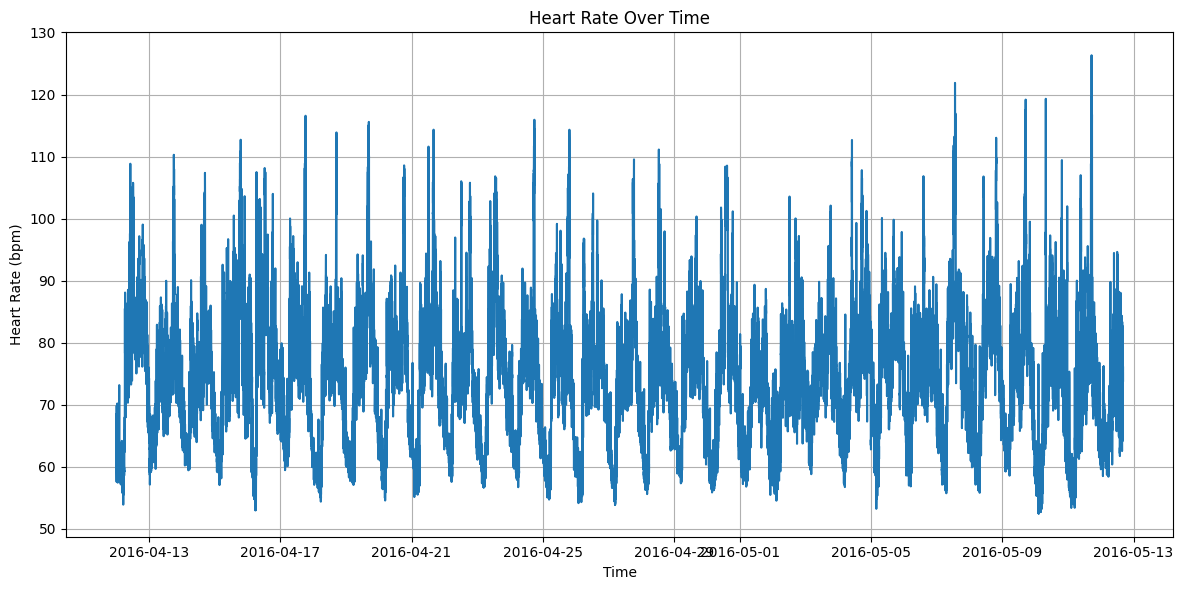

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(final_dataset.index, final_dataset["HeartRate"])
plt.title("Heart Rate Over Time")
plt.xlabel("Time")
plt.ylabel("Heart Rate (bpm)")
plt.grid(True)
plt.tight_layout()
plt.show()

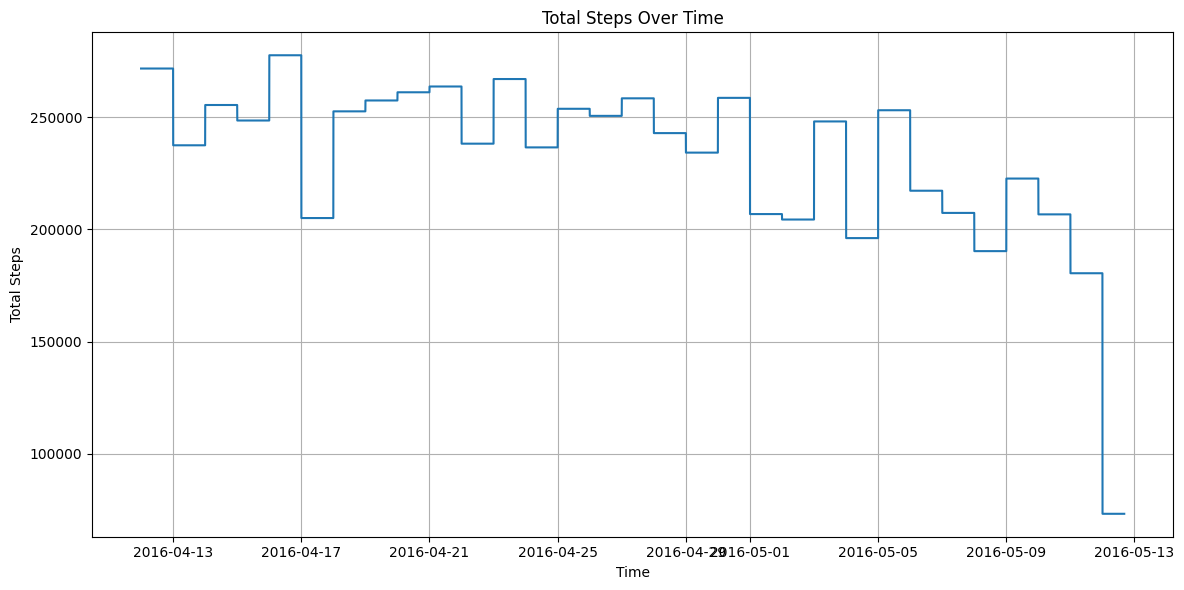

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(final_dataset.index, final_dataset["TotalSteps"])
plt.title("Total Steps Over Time")
plt.xlabel("Time")
plt.ylabel("Total Steps")
plt.grid(True)
plt.tight_layout()
plt.show()

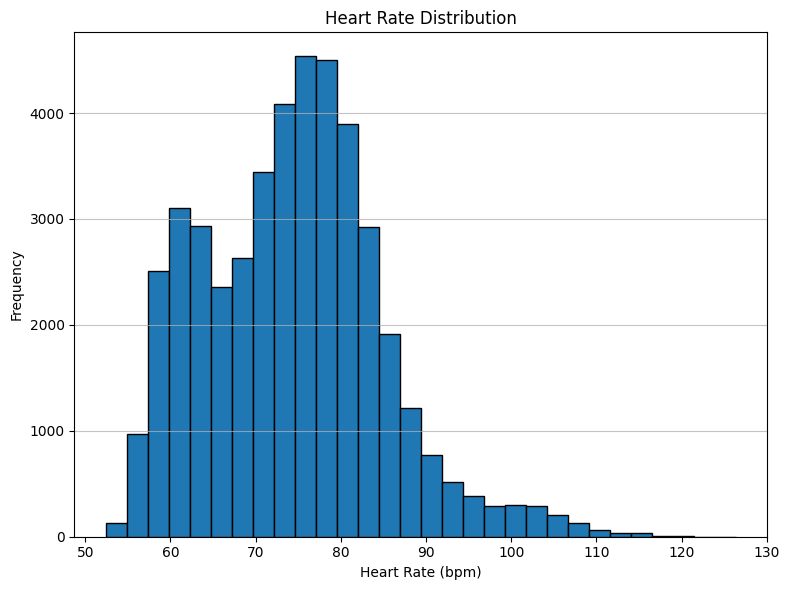

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hist(final_dataset["HeartRate"].dropna(), bins=30, edgecolor='black') # dropna to handle potential NaNs for histogram
plt.title("Heart Rate Distribution")
plt.xlabel("Heart Rate (bpm)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

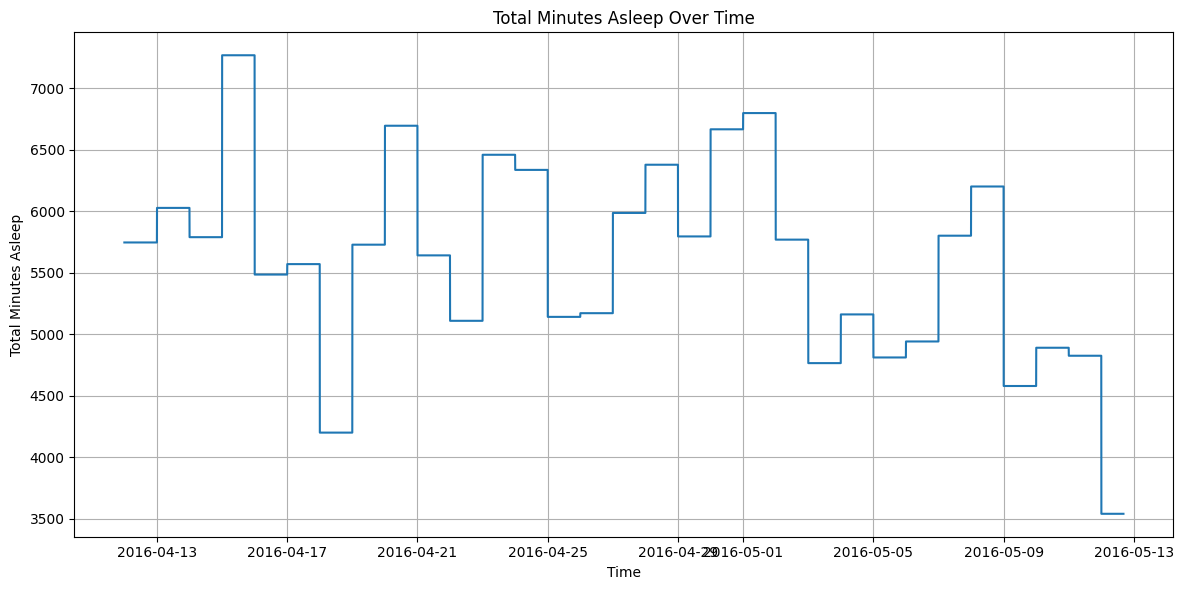

In [47]:
import matplotlib.pyplot as plt

if "TotalMinutesAsleep" in final_dataset.columns:
    plt.figure(figsize=(12,6))
    plt.plot(final_dataset.index, final_dataset["TotalMinutesAsleep"])
    plt.title("Total Minutes Asleep Over Time")
    plt.xlabel("Time")
    plt.ylabel("Total Minutes Asleep")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [48]:
from google.colab import files

cleaned_file = "cleaned_fitness_data_1min.csv"
final_dataset.to_csv(cleaned_file, index=False)

files.download(cleaned_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>